[nltk_data] Downloading package wordnet to /root/nltk_data...


After filtering: 6013 samples, 55 classes
After augmentation: 6013 samples
Classes: 55
Acute conditions: 17

 CNN
 F1: Acc=0.8628 F1=0.8192 AUC=0.9917
 F2: Acc=0.8861 F1=0.8490 AUC=0.9939
 F3: Acc=0.8786 F1=0.8326 AUC=0.9925
 F4: Acc=0.8720 F1=0.8267 AUC=0.9932
 F5: Acc=0.8811 F1=0.8298 AUC=0.9932

 Summary:
 test_acc       : 0.8761 ± 0.0090
 test_loss      : 4.3084 ± 0.0436
 macro_f1       : 0.8315 ± 0.0110
 roc_auc        : 0.9929 ± 0.0008
 top3           : 0.9325 ± 0.0130
 top5           : 0.9520 ± 0.0112
 ece            : 0.0412 ± 0.0091
 brier          : 0.1791 ± 0.0045
 sens_acute     : 0.9450 ± 0.0100

 XGBoost
 F1: Acc=0.7980 F1=0.7534 AUC=0.9817
 F2: Acc=0.7997 F1=0.7547 AUC=0.9831
 F3: Acc=0.7963 F1=0.7458 AUC=0.9828
 F4: Acc=0.8080 F1=0.7589 AUC=0.9824
 F5: Acc=0.7980 F1=0.7512 AUC=0.9830

 Summary:
 test_acc       : 0.8000 ± 0.0046
 test_loss      : 0.7813 ± 0.0116
 macro_f1       : 0.7528 ± 0.0048
 roc_auc        : 0.9826 ± 0.0006
 top3           : 0.8608 ± 0.0076
 top5   

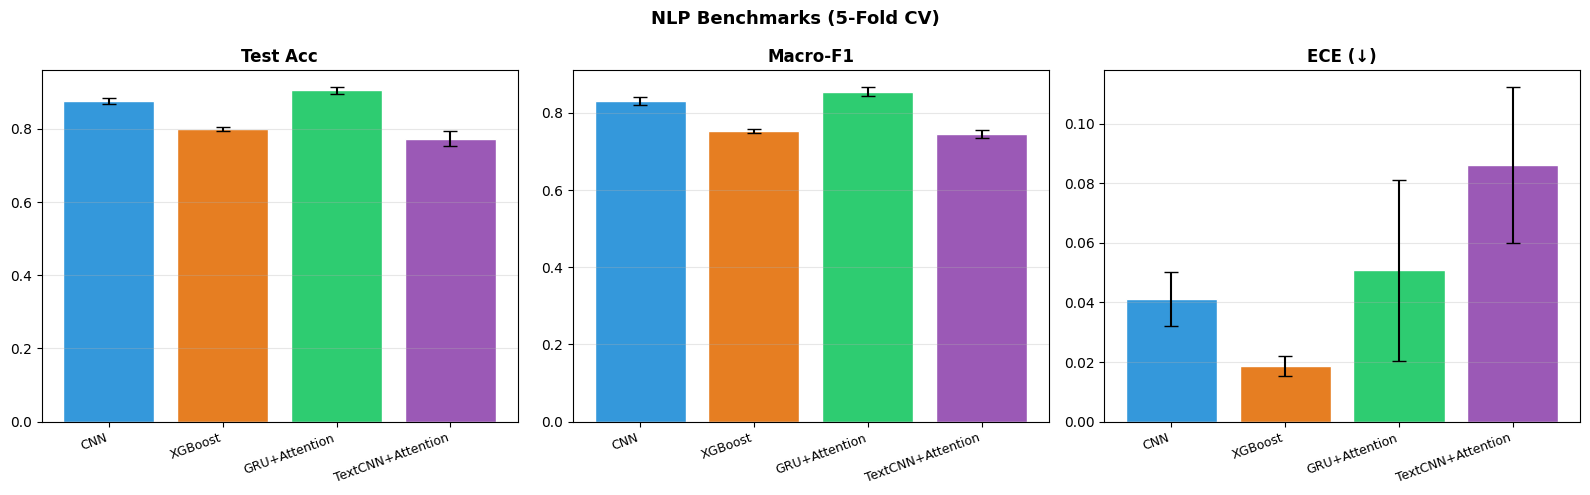


✅ NLP benchmarks complete!


In [2]:
"""
================================================================================
NB5: NLP BENCHMARKS — 5-FOLD CV (Reviewer 1, Point 3)
================================================================================
Models: CNN, XGBoost, GRU+Attention, TextCNN+Attention
Run AFTER NB4 so variables exist, OR paste NB4 Cells 1-2 for standalone.
Values only — no model saving.
================================================================================
"""
# Assumes these from NB4: X_tv, X_te, y_tv, y_te, y_te_ohe, NC, le,
# acute_idx, cw_dict
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
from keras.models import Model
from keras.layers import (Input, Dense, Dropout, Conv1D, Flatten, MaxPooling1D,
                          GRU, Attention, Embedding, BatchNormalization)
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import to_categorical
from keras.regularizers import l2
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, recall_score, top_k_accuracy_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from nltk.corpus import wordnet
import nltk
nltk.download('wordnet')
from xgboost import XGBClassifier
import random, warnings;warnings.filterwarnings('ignore')
os.makedirs('/content/results',exist_ok=True)
os.makedirs('/content/figures',exist_ok=True)

# Paste from NB4 Cell 2 for standalone run
df = pd.read_csv('/content/bert_train.csv')
vc = df['Label'].value_counts()
df = df[df['Label'].isin(vc[vc>1].index)]
print(f"After filtering: {len(df)} samples, {df['Label'].nunique()} classes")

AUG_THRESH = 20
def syn_replace(text, n=1):
    words=text.split(); nw=words.copy()
    wl=list(set([w for w in words if wordnet.synsets(w)]))
    random.shuffle(wl); rep=0
    for rw in wl:
        ss=wordnet.synsets(rw)
        if ss:
            s=ss[0].lemmas()[0].name()
            nw=[s if w==rw else w for w in nw]; rep+=1
        if rep>=n: break
    return ' '.join(nw)

aug=[]
for label, count in df['Label'].value_counts().items():
    if count<AUG_THRESH:
        sub=df[df['Label']==label]
        while count<AUG_THRESH:
            for _,row in sub.iterrows():
                aug.append({'Label':label,'text':syn_replace(row['text'])})
                count+=1
                if count>=AUG_THRESH: break
df = pd.concat([df, pd.DataFrame(aug)], ignore_index=True)
print(f"After augmentation: {len(df)} samples")

X_text = df['text'].values; y_labels = df['Label'].values
tok = Tokenizer(num_words=15000, oov_token="<OOV>")
tok.fit_on_texts(X_text)
X_pad = pad_sequences(tok.texts_to_sequences(X_text), maxlen=200,
                      padding='post', truncating='post')
le = LabelEncoder(); y_enc = le.fit_transform(y_labels)
NC = len(le.classes_)
print(f"Classes: {NC}")

# STRICT SPLIT
X_tv, X_te, y_tv, y_te = train_test_split(
    X_pad, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
y_te_ohe = to_categorical(y_te, NC)
cw = compute_class_weight('balanced', classes=np.unique(y_enc), y=y_enc)
cw_dict = {i:cw[i] for i in range(len(cw))}

acute_labels = ['Heart Attack','Pneumonia','Tuberculosis','Typhoid','Hepatitis E',
                'Dengue','Malaria','Jaundice','Paralysis (Brain Hemorrhage)',
                'Alcoholic Hepatitis','Drug Reaction','Gastroenteritis',
                'Hepatitis A','Hepatitis B','Hepatitis C','Hepatitis D','Aids']
acute_idx = [np.where(le.classes_==l)[0][0] for l in acute_labels if l in le.classes_]
print(f"Acute conditions: {len(acute_idx)}")

def ece_fn(yt,yp,n=10):
    c=np.max(yp,1); p=np.argmax(yp,1); a=(p==yt).astype(float); e=0.0
    for i in range(n):
        bl,bu=i/n,(i+1)/n
        m=(c>=bl)&(c<=bu) if i==n-1 else (c>=bl)&(c<bu)
        pp=np.mean(m)
        if pp>0: e+=np.abs(np.mean(c[m])-np.mean(a[m]))*pp
    return e
def brier(yo,yp): return np.mean(np.sum((yp-yo)**2,1))
# ── Model Builders ──
def mk_cnn():
    i=Input(shape=(200,))
    x=Embedding(15000,256,input_length=200)(i)
    x=Conv1D(256,7,activation='relu',kernel_regularizer=l2(0.01))(x)
    x=BatchNormalization()(x); x=MaxPooling1D(2)(x); x=Dropout(0.4)(x)
    x=Conv1D(128,5,activation='relu',kernel_regularizer=l2(0.01))(x)
    x=BatchNormalization()(x); x=MaxPooling1D(2)(x); x=Dropout(0.3)(x)
    x=Flatten()(x)
    x=Dense(256,activation='relu',kernel_regularizer=l2(0.01))(x)
    x=BatchNormalization()(x); x=Dropout(0.4)(x)
    x=Dense(128,activation='relu',kernel_regularizer=l2(0.01))(x)
    x=BatchNormalization()(x); x=Dropout(0.3)(x)
    o=Dense(NC,activation='softmax')(x)
    m=Model(i,o); m.compile(optimizer=Adam(3e-5,clipvalue=1.0), loss=CategoricalCrossentropy(), metrics=[CategoricalAccuracy(name='accuracy')]); return m
def mk_gru_attn():
    i=Input(shape=(200,))
    x=Embedding(15000,256,input_length=200)(i)
    x=Conv1D(256,7,activation='relu',kernel_regularizer=l2(0.01))(x)
    x=BatchNormalization()(x); x=MaxPooling1D(2)(x); x=Dropout(0.4)(x)
    x=GRU(128,return_sequences=True,kernel_regularizer=l2(0.01))(x)
    x=Attention()([x,x]); x=Flatten()(x); x=Dropout(0.3)(x)
    x=Dense(256,activation='relu',kernel_regularizer=l2(0.01))(x)
    x=BatchNormalization()(x); x=Dropout(0.4)(x)
    x=Dense(128,activation='relu',kernel_regularizer=l2(0.01))(x)
    x=BatchNormalization()(x); x=Dropout(0.3)(x)
    o=Dense(NC,activation='softmax')(x)
    m=Model(i,o); m.compile(optimizer=Adam(3e-5,clipvalue=1.0), loss=CategoricalCrossentropy(), metrics=[CategoricalAccuracy(name='accuracy')]); return m
def mk_textcnn_attn():
    i=Input(shape=(200,))
    x=Embedding(15000,256,input_length=200)(i)
    x=Conv1D(256,7,activation='relu',kernel_regularizer=l2(0.01))(x)
    x=BatchNormalization()(x); x=MaxPooling1D(2)(x); x=Dropout(0.4)(x)
    x=Conv1D(128,5,activation='relu',kernel_regularizer=l2(0.01))(x)
    x=BatchNormalization()(x); x=MaxPooling1D(2)(x); x=Dropout(0.3)(x)
    x=Attention()([x,x]); x=Flatten()(x); x=Dropout(0.3)(x)
    x=Dense(256,activation='relu',kernel_regularizer=l2(0.01))(x)
    x=BatchNormalization()(x); x=Dropout(0.4)(x)
    x=Dense(128,activation='relu',kernel_regularizer=l2(0.01))(x)
    x=BatchNormalization()(x); x=Dropout(0.3)(x)
    o=Dense(NC,activation='softmax')(x)
    m=Model(i,o); m.compile(optimizer=Adam(3e-5,clipvalue=1.0), loss=CategoricalCrossentropy(), metrics=[CategoricalAccuracy(name='accuracy')]); return m
# ── Runner ──
def bench(name, builder, is_keras=True, ep=80, bs=32): # Optimized for free Colab T4
    print(f"\n{'='*55}\n {name}\n{'='*55}")
    skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
    res=[]
    for fold,(ti,vi) in enumerate(skf.split(X_tv,y_tv)):
        Xtr,Xvl,ytr,yvl=X_tv[ti],X_tv[vi],y_tv[ti],y_tv[vi]
        if is_keras:
            mdl=builder()
            mdl.fit(Xtr,to_categorical(ytr,NC),
                    validation_data=(Xvl,to_categorical(yvl,NC)),
                    epochs=ep,batch_size=bs,class_weight=cw_dict,
                    callbacks=[EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True),
                               ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-6)],
                    verbose=0)
            tl,ta=mdl.evaluate(X_te,y_te_ohe,verbose=0)
            yp=mdl.predict(X_te,verbose=0)
        else:
            Xtr_f=Xtr.reshape(Xtr.shape[0],-1)
            Xte_f=X_te.reshape(X_te.shape[0],-1)
            mdl=builder(); mdl.fit(Xtr_f,ytr)
            ta=mdl.score(Xte_f,y_te); yp=mdl.predict_proba(Xte_f)
            tl=-np.mean(np.sum(y_te_ohe*np.log(yp+1e-10),1))
        ypc=np.argmax(yp,1)
        f1=f1_score(y_te,ypc,average='macro')
        t3=top_k_accuracy_score(y_te,yp,k=3)
        t5=top_k_accuracy_score(y_te,yp,k=5)
        ec=ece_fn(y_te,yp); br=brier(y_te_ohe,yp)
        se=recall_score(y_te,ypc,labels=acute_idx,average='macro',zero_division=0)
        try: auc=roc_auc_score(y_te_ohe,yp,average='macro',multi_class='ovr')
        except: auc=0
        print(f" F{fold+1}: Acc={ta:.4f} F1={f1:.4f} AUC={auc:.4f}")
        res.append({'test_acc':ta,'test_loss':tl,'macro_f1':f1,'roc_auc':auc,
'top3':t3,'top5':t5,'ece':ec,'brier':br,'sens_acute':se})
    print(f"\n Summary:")
    for k in res[0]:
        vs=[r[k] for r in res]
        print(f" {k:<15}: {np.mean(vs):.4f} ± {np.std(vs,ddof=1):.4f}")
    return res
# ── Run ──
R={}
R['CNN'] = bench('CNN', mk_cnn)
R['XGBoost'] = bench('XGBoost',
lambda: XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=6,
                          random_state=42,use_label_encoder=False,eval_metric='mlogloss'),
    is_keras=False)
R['GRU+Attention'] = bench('GRU + Attention', mk_gru_attn)
R['TextCNN+Attention'] = bench('TextCNN + Attention', mk_textcnn_attn)
# ── Table ──
print(f"\n{'='*80}\n NLP BENCHMARKS TABLE\n{'='*80}")
rows=[]
for nm,res in R.items():
    row={'Model':nm}
    for k in res[0]:
        vs=[r[k] for r in res]
        row[k]=f"{np.mean(vs):.4f} ± {np.std(vs,ddof=1):.4f}"
    rows.append(row)
df=pd.DataFrame(rows).set_index('Model')
print(df.to_string())
df.to_csv('/content/results/nlp_benchmark_comparison.csv')
# Chart
fig,axes=plt.subplots(1,3,figsize=(16,5))
for ax,mk,tt in zip(axes,['test_acc','macro_f1','ece'],['Test Acc','Macro-F1','ECE (↓)']):
    nms=list(R.keys())
    ms=[np.mean([r[mk] for r in R[n]]) for n in nms]
    ss=[np.std([r[mk] for r in R[n]],ddof=1) for n in nms]
    cs=['#3498DB','#E67E22','#2ECC71','#9B59B6']
    ax.bar(range(len(nms)),ms,yerr=ss,color=cs,capsize=5,edgecolor='white')
    ax.set_xticks(range(len(nms))); ax.set_xticklabels(nms,rotation=20,ha='right',fontsize=9)
    ax.set_title(tt,fontweight='bold'); ax.grid(alpha=0.3,axis='y')
plt.suptitle('NLP Benchmarks (5-Fold CV)',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('/content/figures/nlp_benchmarks.png',dpi=300,bbox_inches='tight')
plt.show()
print("\n✅ NLP benchmarks complete!")